In [1]:
import pandas as pd 
import numpy as np
import joblib
import time
import sklearn.metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support, recall_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier

## Dataset Prepare

In [2]:
def calculate_macro_tpr_fpr(voting_cm):
    num_classes = voting_cm.shape[0]
    tpr_list = []
    fpr_list = []

    for i in range(num_classes):
        TP = voting_cm[i, i]
        FN = np.sum(voting_cm[i, :]) - TP
        FP = np.sum(voting_cm[:, i]) - TP
        TN = np.sum(voting_cm) - (TP + FN + FP)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    macro_tpr = np.mean(tpr_list)
    macro_fpr = np.mean(fpr_list)

    return macro_tpr, macro_fpr

# Load models

In [3]:
test = pd.read_csv('/dis/DS/hungnt/CICModbus2023/test_shap_58_600.csv')

X_test = test.drop(['Label'], axis=1)
y_test = test['Label']

In [4]:
# --- Load models ---
xgb_model = XGBClassifier()
xgb_model = joblib.load('./models/xgb_TabDiff.pkl')

cat_model = CatBoostClassifier()
cat_model = joblib.load('./models/cat_TabDiff.pkl')

rf_model = RandomForestClassifier()
rf_model = joblib.load('./models/rf_TabDiff.pkl')

et_model = ExtraTreesClassifier()
et_model = joblib.load('./models/et_TabDiff.pkl')

lgbm_model = LGBMClassifier()
lgbm_model = joblib.load('./models/lgbm_TabDiff.pkl')

# --- Predict proba ---
xgb_preds = xgb_model.predict_proba(X_test)
cat_preds = cat_model.predict_proba(X_test)
rf_preds  = rf_model.predict_proba(X_test)
et_preds  = et_model.predict_proba(X_test)
lgbm_preds = lgbm_model.predict_proba(X_test)

# --- Predict labels ---
xgb_prediction = xgb_model.predict(X_test)
cat_prediction = cat_model.predict(X_test)
rf_prediction  = rf_model.predict(X_test)
et_prediction  = et_model.predict(X_test)
lgbm_prediction = lgbm_model.predict(X_test)

# --- Accuracy ---
xgb_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=xgb_prediction)
cat_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=cat_prediction)
rf_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=rf_prediction)
et_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=et_prediction)
lgbm_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=lgbm_prediction)

print("XGBoost Accuracy:", xgb_acc)
print("CatBoost Accuracy:", cat_acc)
print("RandomForest Accuracy:", rf_acc)
print("ExtraTrees Accuracy:", et_acc)
print("LightGBM Accuracy:", lgbm_acc)

# --- Macro-F1 ---
print("XGBoost Macro-F1:", f1_score(y_true=y_test, y_pred=xgb_prediction, average="macro"))
print("CatBoost Macro-F1:", f1_score(y_true=y_test, y_pred=cat_prediction, average="macro"))
print("RandomForest Macro-F1:", f1_score(y_true=y_test, y_pred=rf_prediction, average="macro"))
print("ExtraTrees Macro-F1:", f1_score(y_true=y_test, y_pred=et_prediction, average="macro"))
print("LightGBM Macro-F1:", f1_score(y_true=y_test, y_pred=lgbm_prediction, average="macro"))

XGBoost Accuracy: 0.954384186517993
CatBoost Accuracy: 0.9450076026355804
RandomForest Accuracy: 0.9645210339584389
ExtraTrees Accuracy: 0.9627470856563609
LightGBM Accuracy: 0.9548910288900152
XGBoost Macro-F1: 0.9581564641635345
CatBoost Macro-F1: 0.9492192352255694
RandomForest Macro-F1: 0.9679414192035468
ExtraTrees Macro-F1: 0.9662158125375065
LightGBM Macro-F1: 0.9587617391398994


In [5]:
train = pd.read_csv('/home/soc/hungnt/Backup_code_Modbus/Modbus2023_600/gen_data/modbus_train_merged_2800_TabDiff_plus1400_label2.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']

# Weighted Voting Ensemble

In [19]:
# ====== cấu hình ======
metric = "f1"      # "f1" hoặc "recall"
step = 0.05
N = int(round(1 / step))

# ====== danh sách proba của 5 mô hình ======
# Thứ tự: xgb, cat, rf, et, lgbm
preds_list = [
    xgb_preds,
    cat_preds,
    rf_preds,
    et_preds,
    lgbm_preds
]

best_score = -1.0
best_weights = None

# ====== search weights cho 5 mô hình ======
# w1 + w2 + w3 + w4 + w5 = 1
for i in range(N + 1):
    for j in range(N + 1 - i):
        for k in range(N + 1 - i - j):
            for l in range(N + 1 - i - j - k):
                m = N - i - j - k - l   # m >= 0

                w1, w2, w3, w4, w5 = i/N, j/N, k/N, l/N, m/N

                proba = (
                    w1 * preds_list[0] +
                    w2 * preds_list[1] +
                    w3 * preds_list[2] +
                    w4 * preds_list[3] +
                    w5 * preds_list[4]
                )

                pred = proba.argmax(axis=1)

                if metric == "f1":
                    score = f1_score(
                        y_test, pred,
                        average='macro',
                        zero_division=0
                    )
                else:
                    score = recall_score(
                        y_test, pred,
                        average='macro',
                        zero_division=0
                    )

                if score > best_score:
                    best_score = score
                    best_weights = (w1, w2, w3, w4, w5)

print("Best weights (w1..w5):", best_weights, "sum =", sum(best_weights))
print(f"Best {metric} (macro):", best_score)

# ====== AUC macro OVR tại trọng số tốt nhất ======
w1, w2, w3, w4, w5 = best_weights
proba_best = (
    w1 * preds_list[0] +
    w2 * preds_list[1] +
    w3 * preds_list[2] +
    w4 * preds_list[3] +
    w5 * preds_list[4]
)

try:
    auc_macro_ovr = roc_auc_score(
        y_test,
        proba_best,
        multi_class='ovr',
        average='macro'
    )
    print("AUC (macro, OVR):", auc_macro_ovr)
except ValueError as e:
    print("AUC không tính được:", e)

Best weights (w1..w5): (0.05, 0.0, 0.25, 0.6, 0.1) sum = 0.9999999999999999
Best f1 (macro): 0.9698326387191548
AUC (macro, OVR): 0.9986929493716499


In [15]:
avgs = (
    w1 * xgb_preds +
    w2 * cat_preds +
    w3 * rf_preds +
    w4 * et_preds +
    w5 * lgbm_preds
)

voting_prediction = avgs.argmax(axis=1)
voting_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=voting_prediction)
voting_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=voting_prediction)


# AUC-ROC calculation
# Convert y_test to binary indicator matrix if it isn't already
if y_test.ndim == 1 or y_test.shape[1] == 1:
    from sklearn.preprocessing import label_binarize
    y_test_binary = label_binarize(y_test, classes=range(avgs.shape[1]))
else:
    y_test_binary = y_test

# Compute the probabilities for each class
voting_probabilities = avgs / avgs.sum(axis=1, keepdims=True)  # Normalize probabilities

# Compute AUC-ROC for each label
auc_roc = sklearn.metrics.roc_auc_score(y_test_binary, voting_probabilities, average='macro', multi_class='ovr')

print("Voting report:")
print("Voting Accuracy:", voting_acc)
print("Voting Precision:", voting_precision)
print("Voting F1:", voting_f1)
print("Voting Recall:", voting_recall)
print("Voting AUC-ROC:", auc_roc)
print("Voting CM:\n", voting_cm)
voting_tpr, voting_fpr = calculate_macro_tpr_fpr(voting_cm)
print(f'Voting Macro-average TPR: {voting_tpr}')
print(f'Voting Macro-average FPR: {voting_fpr}')
print(classification_report(y_test, voting_prediction, digits=4))

Voting report:
Voting Accuracy: 0.9668018246325393
Voting Precision: 0.9696494852801413
Voting F1: 0.9698326387191548
Voting Recall: 0.970538755436271
Voting AUC-ROC: 0.9986929493716499
Voting CM:
 [[597   1   1   0   0   0   0   1   0]
 [  0 538   2   0   0   3   0   0   8]
 [  0  11 546   0   0   9   0   0  34]
 [  0   0   0  26   0   0   0   0   0]
 [  0   0   0   0 455   0   1   0   0]
 [  2  13   0   0   0 404   1   0   1]
 [  2   7   0   0   0   6 431   0   1]
 [  2   0   0   0   0   0   0 451   0]
 [  0   8  13   0   0   4   0   0 367]]
Voting Macro-average TPR: 0.970538755436271
Voting Macro-average FPR: 0.004204053030066158
              precision    recall  f1-score   support

           0     0.9900    0.9950    0.9925       600
           1     0.9308    0.9764    0.9531       551
           2     0.9715    0.9100    0.9398       600
           3     1.0000    1.0000    1.0000        26
           4     1.0000    0.9978    0.9989       456
           5     0.9484    0.9596 

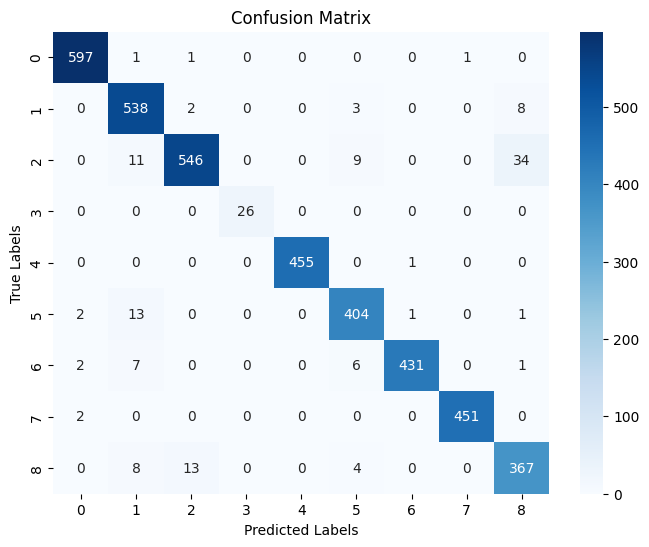

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(voting_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()